In [2]:
import os
import sys
import numpy as np
import torch
import h5py
import pyresample
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import xarray as xr
from pathlib import Path
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

# ── Add model code to path ────────────────────────────────────────────────────
CODE_DIR = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Code'
sys.path.insert(0, CODE_DIR)
from lib.model.FusionNetASPP import FusionNetASPP
from grid_config import target_area

# ── Config ────────────────────────────────────────────────────────────────────
CKPT_DIR  = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/training'
SWATH_DIR = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Data/for_suman'   # update this
MODEL_NAME = 'FusionNetASPP'
FEATURES   = 128
POSTFIX    = 5
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

shp = gpd.read_file(f'{CODE_DIR}/lib/predict/arctic_shp/op_str_maps_circum_polar_40_EPSG3411.shp')

# ── Load model ────────────────────────────────────────────────────────────────
CKPT_PATH = os.path.join(CKPT_DIR, MODEL_NAME.lower(), f'best_model_{POSTFIX}.pth')
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model = FusionNetASPP(in_channels=ckpt['in_channels'], features=ckpt['features']).to(device)
ckpt  = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Model loaded from epoch {ckpt["epoch"]} — val_loss={ckpt["val_loss"]:.4f}')

swath_files = sorted(Path(SWATH_DIR).glob('*resampled.nc'))
print(f"Found {len(swath_files)} resampled file(s)")

SWATH_PATH = swath_files[0]  # Use the first file for testing
# ── Load AMSR2 ────────────────────────────────────────────────────────────────
with xr.open_dataset(SWATH_PATH, engine='netcdf4') as ds:
    tb_channels = []
    for var in ['btemp_6.9h', 'btemp_6.9v', 'btemp_7.3h', 'btemp_7.3v',
                'btemp_10.7h', 'btemp_10.7v', 'btemp_18.7h', 'btemp_18.7v',
                'btemp_23.8h', 'btemp_23.8v', 'btemp_36.5h', 'btemp_36.5v',
                'btemp_89.0h', 'btemp_89.0v']:
        tb_channels.append(ds[var].values.astype(np.float32))
    amsr2_full = np.stack(tb_channels, axis=0)  # (14, 4510, 4510)

Model loaded from epoch 214 — val_loss=2.3710
Found 29 resampled file(s)


In [ ]:
for SWATH_PATH in swath_files:
    # ── Load all channels ─────────────────────────────────────────────────────
    with xr.open_dataset(SWATH_PATH, engine='netcdf4') as ds:
        # drop non-btemp variables (e.g. swath_segmentation) from the channel grid
        channels = {var: ds[var].values.astype(np.float32)
                    for var in ds.data_vars if 'btemp' in var}

    n_channels = len(channels)
    if n_channels == 0:
        print(f"  Skipped (no btemp variables found): {SWATH_PATH.name}")
        continue

    # ── Plot ──────────────────────────────────────────────────────────────────
    ncols = 4
    nrows = int(np.ceil(n_channels / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 4, nrows * 4),
                              gridspec_kw={'hspace': 0.3, 'wspace': 0.1})
    axes = np.atleast_1d(axes).ravel()

    cmap = plt.cm.RdYlBu_r.copy()
    cmap.set_bad('lightgray')

    i = 0
    for i, (name, data) in enumerate(channels.items()):
        ax = axes[i]

        if np.isnan(data).all():
            ax.axis('off')
            ax.set_title(f'{name}\n(all NaN)', fontsize=9)
            continue

        p2, p98 = np.nanpercentile(data, 2), np.nanpercentile(data, 98)

        im = ax.imshow(data, cmap=cmap, vmin=p2, vmax=p98,
                       interpolation='nearest', origin='upper')
        ax.set_title(f'{name}\n{p2:.0f}–{p98:.0f} K', fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # fig.suptitle(f'AMSR2 brightness temperatures — {n_channels} channels\n{SWATH_PATH.name}',
                #  fontsize=11)

    plt.show()

In [13]:
TILE_SIZE = 128
OVERLAP   = 32
STRIDE    = TILE_SIZE - OVERLAP
EDGE_TRIM = 4   # columns/rows at each tile edge considered unreliable

H, W = amsr2_full.shape[1], amsr2_full.shape[2]
sic_full   = np.full((H, W), np.nan, dtype=np.float32)
count_full = np.zeros((H, W), dtype=np.float32)

for y in range(0, H, STRIDE):
    for x in range(0, W, STRIDE):
        y1 = min(y + TILE_SIZE, H)
        x1 = min(x + TILE_SIZE, W)
        tile = amsr2_full[:, y:y1, x:x1]

        th, tw = tile.shape[1], tile.shape[2]
        ph, pw = TILE_SIZE - th, TILE_SIZE - tw

        tile_in = np.nan_to_num(tile, nan=0.0)
        if ph > 0 or pw > 0:
            tile_in = np.pad(tile_in, ((0,0),(0,ph),(0,pw)), constant_values=0.0)

        tile_tensor = torch.from_numpy(tile_in).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(tile_tensor, target_size=(TILE_SIZE, TILE_SIZE))

        pred_np = pred[0, 0].cpu().numpy()

        # mark unreliable tile edges as NaN (in full 512x512 tile space)
        pred_np[:, :EDGE_TRIM]  = np.nan
        pred_np[:, -EDGE_TRIM:] = np.nan
        pred_np[:EDGE_TRIM, :]  = np.nan
        pred_np[-EDGE_TRIM:, :] = np.nan

        # crop back to the actual (unpadded) tile size
        pred_np = pred_np[:th, :tw]

        # only blend in pixels where this tile's prediction is valid
        valid_pred = ~np.isnan(pred_np)

        existing      = sic_full[y:y1, x:x1]
        existing_cnt  = count_full[y:y1, x:x1]
        has_existing  = ~np.isnan(existing)

        new_val = np.where(
            has_existing,
            (np.nan_to_num(existing) * existing_cnt + np.nan_to_num(pred_np)) /
            np.maximum(existing_cnt + 1, 1),
            pred_np)

        # where this tile's pred is invalid, keep whatever was already there
        sic_full[y:y1, x:x1] = np.where(valid_pred, new_val, existing)
        count_full[y:y1, x:x1] += valid_pred.astype(np.float32)

# mask out anything that was never actually swath data
orig_nan_mask = np.any(np.isnan(amsr2_full), axis=0)
sic_full[orig_nan_mask] = np.nan
sic_full[count_full == 0] = np.nan

print('Inference done')

Inference done


In [ ]:
H, W = amsr2_full.shape[1], amsr2_full.shape[2]

# Track where the original swath actually had data (vs. fill/no-data)
orig_nan_mask = np.any(np.isnan(amsr2_full), axis=0)

# Replace NaNs with 0 for model input
full_in = np.nan_to_num(amsr2_full, nan=0.0)

tensor = torch.from_numpy(full_in).unsqueeze(0).to(device)
with torch.no_grad():
    pred = model(tensor, target_size=(H, W))

sic_full = pred[0, 0].cpu().numpy()

# Mask out anything that was never actually swath data
sic_full[orig_nan_mask] = np.nan

print('Inference done')

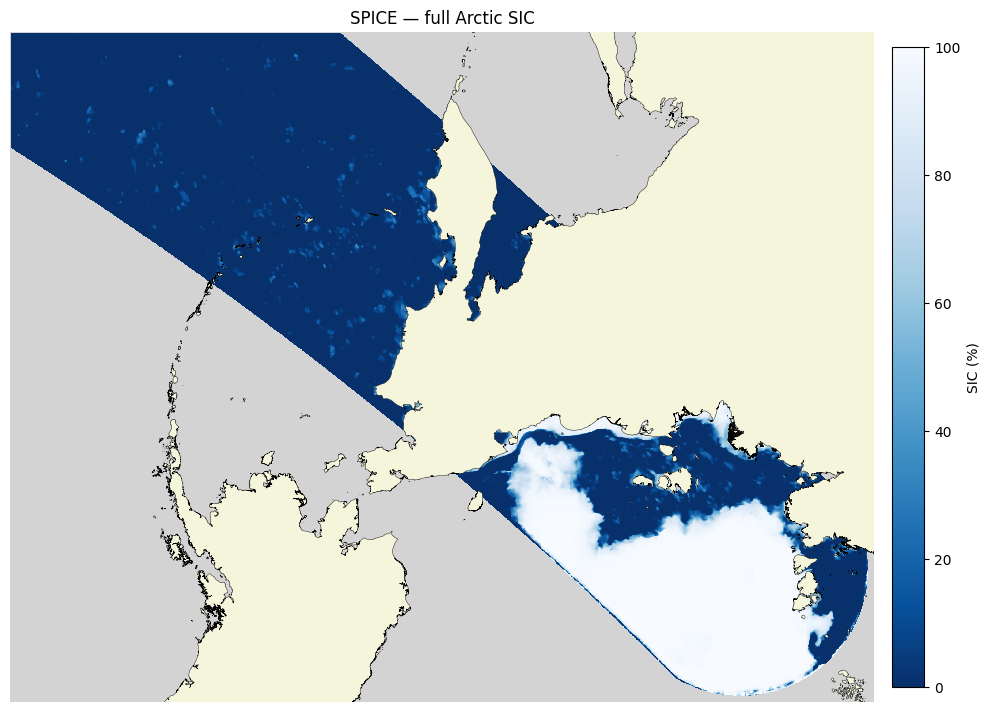

In [14]:
# ── Plot ──────────────────────────────────────────────────────────────────────
x_coords = np.linspace(target_area.area_extent[0],
                        target_area.area_extent[2],
                        target_area.width)
y_coords = np.linspace(target_area.area_extent[3],
                        target_area.area_extent[1],
                        target_area.height)

cmap = plt.cm.Blues_r.copy()
cmap.set_bad('lightgray')
norm = mcolors.Normalize(vmin=0, vmax=100)

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor('black')
ax.pcolormesh(x_coords, y_coords, sic_full,
              cmap=cmap, norm=norm, shading='auto', zorder=3)
shp.to_crs('EPSG:3411').plot(ax=ax, color='beige',
                              edgecolor='black', linewidth=0.3, zorder=4)
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm),
             ax=ax, fraction=0.035, pad=0.02, label='SIC (%)')

# ── Zoom to the extent of valid (non-NaN) data on the 2 km grid ───────────────
H, W = sic_full.shape
valid_mask = ~np.isnan(sic_full)
rows = np.any(valid_mask, axis=1)
cols = np.any(valid_mask, axis=0)

if rows.any() and cols.any():
    row_idx = np.where(rows)[0]
    col_idx = np.where(cols)[0]

    margin = 20  # pixels of padding around the swath
    y0 = max(row_idx.min() - margin, 0)
    y1 = min(row_idx.max() + margin, H - 1)
    x0 = max(col_idx.min() - margin, 0)
    x1 = min(col_idx.max() + margin, W - 1)

    xlim = (x_coords[x0], x_coords[x1])
    ylim = (y_coords[y0], y_coords[y1])

    ax.set_xlim(min(xlim), max(xlim))
    ax.set_ylim(min(ylim), max(ylim))

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('SPICE — full Arctic SIC', fontsize=12)
plt.tight_layout()
plt.show()

Found 29 swath file(s)
Processing GW1AM2_202210130046_181A_L1SGBTBR_2220220_resampled.nc (2022-10-13 00:46:00)
Processing GW1AM2_202210130135_197D_L1SGBTBR_2220220_resampled.nc (2022-10-13 01:35:00)
Processing GW1AM2_202210130225_197A_L1SGBTBR_2220220_resampled.nc (2022-10-13 02:25:00)
Processing GW1AM2_202210130314_213D_L1SGBTBR_2220220_resampled.nc (2022-10-13 03:14:00)
Processing GW1AM2_202210130403_213A_L1SGBTBR_2220220_resampled.nc (2022-10-13 04:03:00)
Processing GW1AM2_202210130453_229D_L1SGBTBR_2220220_resampled.nc (2022-10-13 04:53:00)
Processing GW1AM2_202210130542_229A_L1SGBTBR_2220220_resampled.nc (2022-10-13 05:42:00)
Processing GW1AM2_202210130632_012D_L1SGBTBR_2220220_resampled.nc (2022-10-13 06:32:00)
Processing GW1AM2_202210130721_012A_L1SGBTBR_2220220_resampled.nc (2022-10-13 07:21:00)
Processing GW1AM2_202210130811_028D_L1SGBTBR_2220220_resampled.nc (2022-10-13 08:11:00)
Processing GW1AM2_202210130900_028A_L1SGBTBR_2220220_resampled.nc (2022-10-13 09:00:00)
Processin

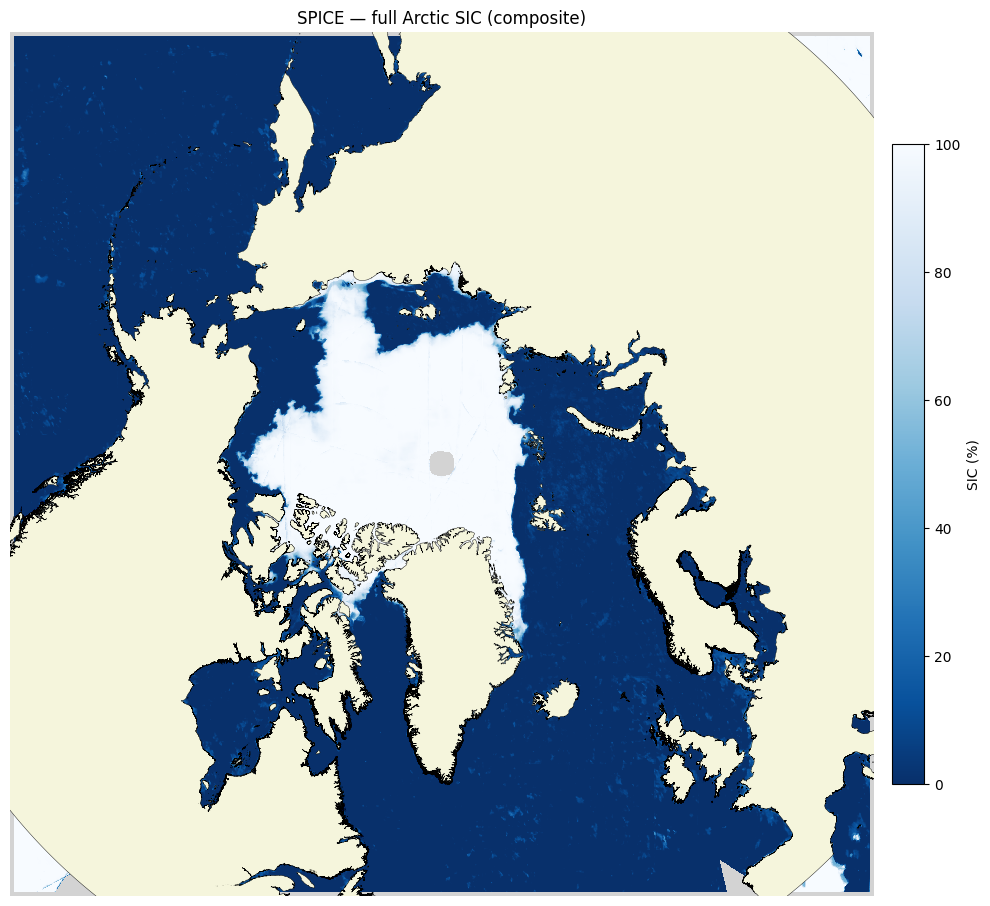

In [ ]:
import os
import re
import glob
from datetime import datetime

import numpy as np
import xarray as xr
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import binary_erosion

# ── Config ─────────────────────────────────────────────────────────────────────
TILE_SIZE = 128
OVERLAP   = 16
STRIDE    = TILE_SIZE - OVERLAP
EDGE_TRIM = 4

TRIM_PIXELS = 20  # how many pixels to shave off each swath's outer edge before compositing

# channel order must match what the model was trained on
CHANNELS = [
    "btemp_6.9h", "btemp_6.9v",
    "btemp_7.3h", "btemp_7.3v",
    "btemp_10.7h", "btemp_10.7v",
    "btemp_18.7h", "btemp_18.7v",
    "btemp_23.8h", "btemp_23.8v",
    "btemp_36.5h", "btemp_36.5v",
    "btemp_89.0h", "btemp_89.0v",
]

# assumes `model`, `device`, `target_area`, `shp`, `SWATH_DIR` are already defined in the session


def parse_swath_time(filename):
    """Extract acquisition datetime from e.g. GW1AM2_202210130135_197D_...nc"""
    match = re.search(r"_(\d{12})_", os.path.basename(filename))
    if match:
        return datetime.strptime(match.group(1), "%Y%m%d%H%M")
    # fallback: use file modification time if the pattern isn't found
    return datetime.fromtimestamp(os.path.getmtime(filename))


def load_swath(filepath):
    """Load a resampled swath .nc file into a (C, H, W) array in CHANNELS order."""
    ds = xr.open_dataset(filepath)
    arrs = [ds[ch].values.astype(np.float32) for ch in CHANNELS]
    ds.close()
    return np.stack(arrs, axis=0)


def trim_edges(valid_mask, trim_pixels=15):
    """Shrink a swath's valid region inward by trim_pixels, dropping the
    unreliable boundary before compositing."""
    if trim_pixels <= 0:
        return valid_mask
    structure = np.ones((3, 3), dtype=bool)
    return binary_erosion(valid_mask, structure=structure, iterations=trim_pixels)


def predict_sic(amsr2_full):
    """Tile-wise inference on a single swath's (C, H, W) raw brightness temp array.
    No normalization (model was trained on raw Kelvin), every tile is run
    regardless of NaN content, invalid pixels are zero-filled."""
    H, W = amsr2_full.shape[1], amsr2_full.shape[2]
    sic_full   = np.full((H, W), np.nan, dtype=np.float32)
    count_full = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H, STRIDE):
        for x in range(0, W, STRIDE):
            y1 = min(y + TILE_SIZE, H)
            x1 = min(x + TILE_SIZE, W)
            tile = amsr2_full[:, y:y1, x:x1]

            th, tw = tile.shape[1], tile.shape[2]
            ph, pw = TILE_SIZE - th, TILE_SIZE - tw

            tile_in = np.nan_to_num(tile, nan=0.0)
            if ph > 0 or pw > 0:
                tile_in = np.pad(tile_in, ((0, 0), (0, ph), (0, pw)), constant_values=0.0)

            tile_tensor = torch.from_numpy(tile_in).unsqueeze(0).to(device)
            with torch.no_grad():
                pred = model(tile_tensor, target_size=(TILE_SIZE, TILE_SIZE))

            pred_np = pred[0, 0].cpu().numpy()

            pred_np[:, :EDGE_TRIM]  = np.nan
            pred_np[:, -EDGE_TRIM:] = np.nan
            pred_np[:EDGE_TRIM, :]  = np.nan
            pred_np[-EDGE_TRIM:, :] = np.nan

            pred_np = pred_np[:th, :tw]
            valid_pred = ~np.isnan(pred_np)

            existing     = sic_full[y:y1, x:x1]
            existing_cnt = count_full[y:y1, x:x1]
            has_existing = ~np.isnan(existing)

            new_val = np.where(
                has_existing,
                (np.nan_to_num(existing) * existing_cnt + np.nan_to_num(pred_np)) /
                np.maximum(existing_cnt + 1, 1),
                pred_np)

            sic_full[y:y1, x:x1] = np.where(valid_pred, new_val, existing)
            count_full[y:y1, x:x1] += valid_pred.astype(np.float32)

    orig_nan_mask = np.any(np.isnan(amsr2_full), axis=0)
    sic_full[orig_nan_mask] = np.nan
    sic_full[count_full == 0] = np.nan
    return sic_full


# ── Gather files, sorted oldest → newest ───────────────────────────────────────
swath_files = sorted(
    glob.glob(os.path.join(SWATH_DIR, "*resampled.nc")),
    key=parse_swath_time
)
print(f"Found {len(swath_files)} swath file(s)")

# ── Run inference per swath, trim edges, composite by averaging overlaps ───────
H, W = target_area.height, target_area.width
sic_sum   = np.zeros((H, W), dtype=np.float32)
sic_count = np.zeros((H, W), dtype=np.float32)

for f in swath_files:
    t = parse_swath_time(f)
    print(f"Processing {os.path.basename(f)} ({t})")

    amsr2_full = load_swath(f)
    sic_swath  = predict_sic(amsr2_full)

    valid = ~np.isnan(sic_swath)
    valid_trimmed = trim_edges(valid, trim_pixels=TRIM_PIXELS)

    sic_sum[valid_trimmed]   += sic_swath[valid_trimmed]
    sic_count[valid_trimmed] += 1

sic_composite = np.where(sic_count > 0, sic_sum / np.maximum(sic_count, 1), np.nan)

print("All swaths processed")

# ── Plot ────────────────────────────────────────────────────────────────────────
x_coords = np.linspace(target_area.area_extent[0],
                        target_area.area_extent[2],
                        target_area.width)
y_coords = np.linspace(target_area.area_extent[3],
                        target_area.area_extent[1],
                        target_area.height)

cmap = plt.cm.Blues_r.copy()
cmap.set_bad('lightgray')
norm = mcolors.Normalize(vmin=0, vmax=100)

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor('black')
ax.pcolormesh(x_coords, y_coords, sic_composite,
              cmap=cmap, norm=norm, shading='auto', zorder=4)
shp.to_crs('EPSG:3411').plot(ax=ax, facecolor='#c8c8a0', edgecolor='gray',
             linewidth=0.1, zorder=5)
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm),
             ax=ax, fraction=0.035, pad=0.02, label='SIC (%)')

# zoom to extent of valid composite data
valid_mask = ~np.isnan(sic_composite)
rows = np.any(valid_mask, axis=1)
cols = np.any(valid_mask, axis=0)
if rows.any() and cols.any():
    row_idx = np.where(rows)[0]
    col_idx = np.where(cols)[0]
    margin = 20
    y0 = max(row_idx.min() - margin, 0)
    y1 = min(row_idx.max() + margin, H - 1)
    x0 = max(col_idx.min() - margin, 0)
    x1 = min(col_idx.max() + margin, W - 1)
    ax.set_xlim(min(x_coords[x0], x_coords[x1]), max(x_coords[x0], x_coords[x1]))
    ax.set_ylim(min(y_coords[y0], y_coords[y1]), max(y_coords[y0], y_coords[y1]))
    # margin = 20
    # INSET = 500  # extra pixels to pull inward from each edge, tune this

    # y0 = max(row_idx.min() - margin + INSET, 0)
    # y1 = min(row_idx.max() + margin - INSET, H - 1)
    # x0 = max(col_idx.min() - margin + INSET, 0)
    # x1 = min(col_idx.max() + margin - INSET, W - 1)

    # ax.set_xlim(min(x_coords[x0], x_coords[x1]), max(x_coords[x0], x_coords[x1]))
    # ax.set_ylim(min(y_coords[y0], y_coords[y1]), max(y_coords[y0], y_coords[y1]))

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('SPICE — full Arctic SIC (composite)', fontsize=12)
plt.tight_layout()
plt.show()